In [3]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [35]:
X,y=make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

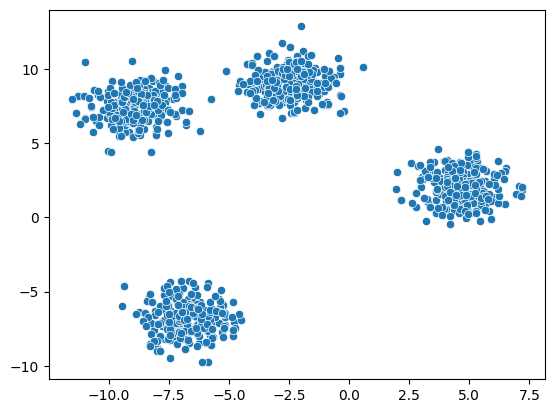

In [13]:
#visualize
sns.scatterplot(x=X[:,0],y=X[:,1])

In [14]:
#kmeans clustering
from sklearn.cluster import KMeans
K=4
kmeans=KMeans(
    n_clusters=K,
    random_state=42
)

<Axes: >

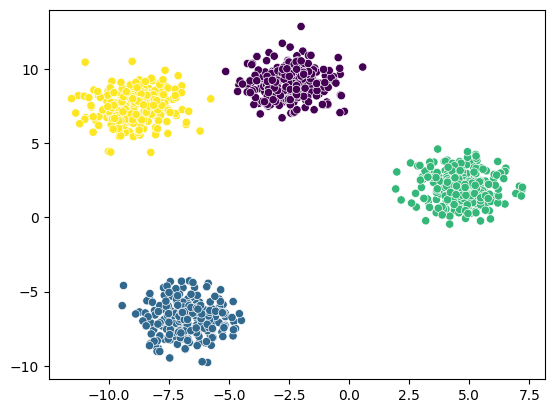

In [16]:
labels=kmeans.fit_predict(X)
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)


#chose k value using elbow or silhouette score

In [36]:
#elbow method
wcss=[]
for k in range(1,21):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

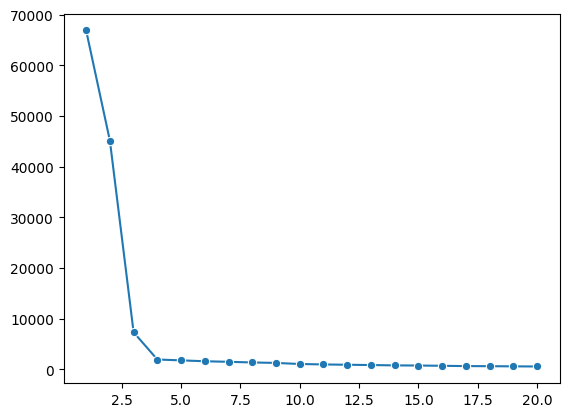

In [22]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')


In [23]:
!pip install kneed

In [27]:
from kneed import KneeLocator

In [37]:
knee=KneeLocator(range(1,21),wcss,curve="convex",direction="decreasing")
print("optimal K=",knee.elbow)

optimal K= 4


#silhouette score

In [38]:
from sklearn.metrics import silhouette_score

In [40]:
ss=[]
for k in range(2,21):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(X)
    ss.append(silhouette_score(X,labels))

<Axes: >

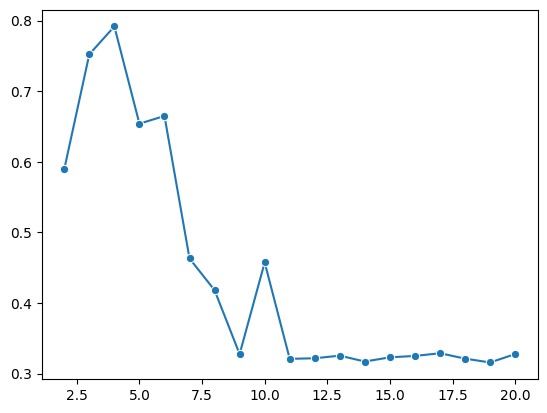

In [41]:
sns.lineplot(x=range(2,21),y=ss,marker='o')
